# Shannon Gourds: Python Assessment

**Academic Integrity Notice**

> Your submission must be your own work. You should be prepared to explain any code or answers you submit if asked.  
> Use of generative AI tools (such as ChatGPT, Copilot, Gemini, etc.) to create or modify code or text for this assessment is not permitted.  
> If you consulted any external resources (such as documentation or tutorials), you must include the full URL of each site you used with your answer.

**Datasets**
For this assessment you have been provided a single dataset, `gourds.csv`. This dataset contains the results of the Great Pumpkin Commonwealth Weighoff for the years 2013 through 2021. The columns of this dataframe are contained in the data dictionary.md file.

## 1. Create a Jupyter notebook and name it . For example, John Smith's notebook would be named john_gourds.ipynb

## 2. Read in the gourds data into a DataFrame named gourds and look at the top 5 rows.

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

In [2]:
gourds = pd.read_csv("../data/gourds.csv")
gourds.head()

,id,place,weight_lbs,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,variety,place_bk,year_bk,type_bk
0,2013-F,1,154.5,"Ellenbecker, Todd & Sequoia",Gleason,Wisconsin,United States,Nekoosa Giant Pumpkin Fest,209 Werner,Self,184.0,129.0,NaN,1.0,2013,F
1,2013-F,2,146.5,"Razo, Steve",New Middletown,Ohio,United States,Ohio Valley Giant Pumpkin Growers Weigh-off,150.5 Snyder,NaN,194.0,151.0,NaN,2.0,2013,F
2,2013-F,3,145.0,"Ellenbecker, Todd & Sequoia",Glenson,Wisconsin,United States,Mishicot Pumpkin Fest,209 Werner,103 Mackinnon,177.0,115.0,NaN,3.0,2013,F
3,2013-F,4,140.8,"Martin, Margaret & Glen",Combined Locks,Wisconsin,United States,Cedarburg Wine and Harvest Festival,109 Martin '12,209 Werner '12,194.0,151.0,NaN,4.0,2013,F
4,2013-F,5,139.0,"Barlow, John",NaN,Wisconsin,United States,Stillwater Harvestfest,130.5 McKinnon,open,0.0,0.0,NaN,5.0,2013,F


## 3. Create a visualization (your choice) which shows the distribution of weights across the dataset.
What do you notice from this visualization?

<Axes: title={'center': 'Gourds: Weight - LBS'}, xlabel='Weight', ylabel='Frequency'>

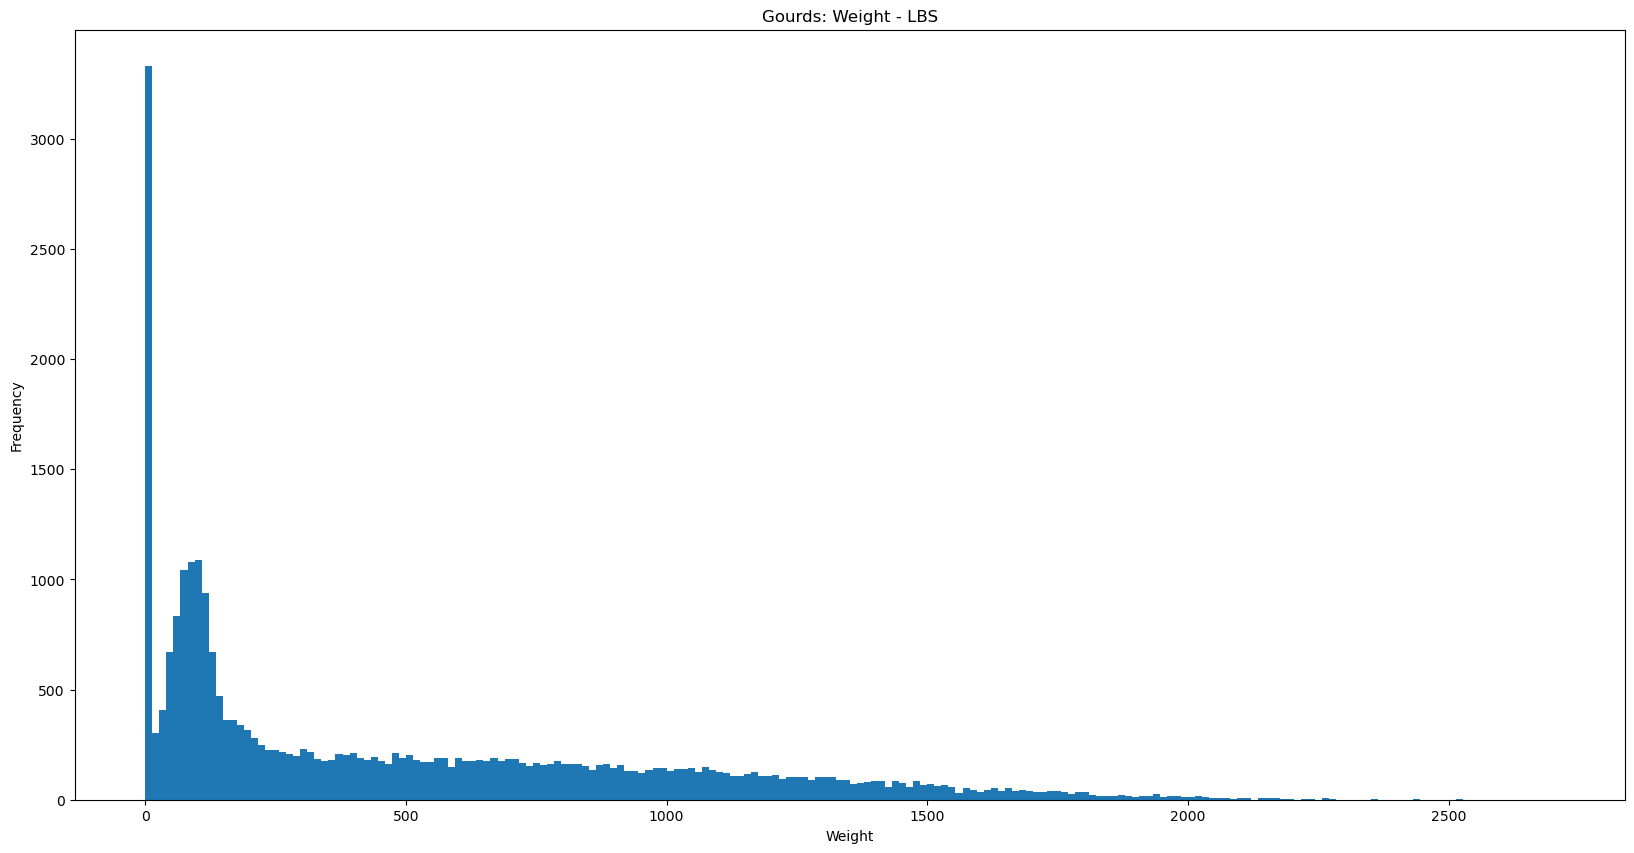

In [3]:
gourds['weight_lbs'].plot(kind="hist", bins=200, figsize=(20, 10), title="Gourds: Weight - LBS", xlabel="Weight")

### ANSWER: The data skews right. The majority of weights are under 500 lbs.

## 4. The place column contains the finishing position of a gourd within its category for a given year.
Convert this column to a numeric type. (Note: this column contains two non-numeric values - 'EXH' and 'DMG'. You can replace these values with NaN.). If you cannot find a solution for this question, you can use the place_bk column in order to answer the questions that follow that rely on it.

In [4]:
gourds['place'] = pd.to_numeric(gourds['place'], errors="coerce")
gourds['place'].dtype

dtype('float64')

## 5. Which country shows up the most frequently in the dataset?
Create a visualization (your choice) to show the frequency of appearances for the top 5 countries in terms of number of appearances.

<Axes: title={'center': 'Top 5 Countries by Apperance'}, xlabel='Country', ylabel='Appearances'>

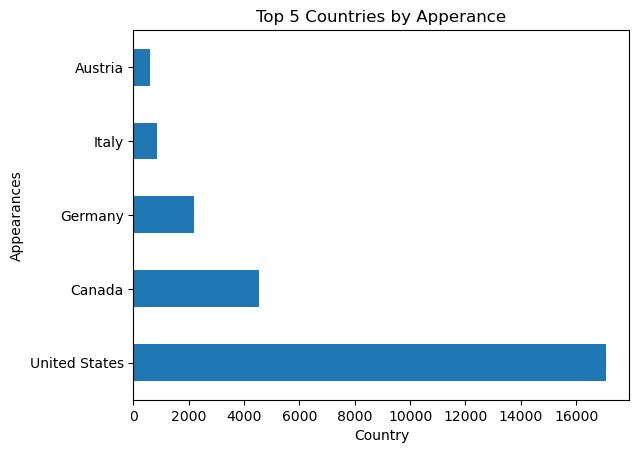

In [5]:
gourds['country'].value_counts().head().plot(kind="barh", title="Top 5 Countries by Apperance", xlabel="Country", ylabel="Appearances")

## 6. The `id` column contains contains a concatenation of the year and an abbreviation for the type of gourd.
For example "2013-F" means that this record is from the year 2013, and the gourd is of type "F" (which stands for Field Pumpkin). Create two new columns, `year` and `type` by extracting these values from the `id` column. If you cannot find a solution for this question, you can use the `year_bk` and `type_bk` columns to answer the questions below that rely on it.

In [6]:
# https://www.geeksforgeeks.org/pandas/python-pandas-split-strings-into-two-list-columns-using-str-split/
id_split = gourds['id'].str.split("-", expand=True)
gourds['year'] = id_split[0]
gourds['type'] = id_split[1]
gourds.head(1)

,id,place,weight_lbs,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,variety,place_bk,year_bk,type_bk,year,type
0,2013-F,1.0,154.5,"Ellenbecker, Todd & Sequoia",Gleason,Wisconsin,United States,Nekoosa Giant Pumpkin Fest,209 Werner,Self,184.0,129.0,NaN,1.0,2013,F,2013,F


## 7. Create a line plot showing the trend in the **heaviest** gourd by year. What do you notice?

<Axes: title={'center': 'Heaviest Gourd by Year'}, xlabel='Year', ylabel='LBS'>

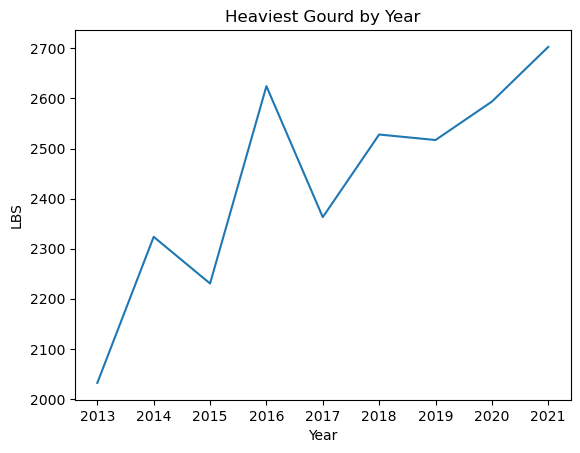

In [7]:
(
    gourds
    .groupby("year")['weight_lbs']
    .max()
    .plot(kind="line", title="Heaviest Gourd by Year", xlabel="Year", ylabel="LBS")
)

### ANSWER: The heaviest gourd weight is trending up from 2013 to 2021 almost 700 lbs.

## 8. Replace the type abbreviations with the full names of each type. 
    ```
    "F": "Field Pumpkin"
    "P": "Giant Pumpkin"
    "S": "Giant Squash"
    "W": "Giant Watermelon"
    "T": "Tomato"
    "L": "Long Gourd"
    ```
    Which type of gourd is heaviest on average? Create a visualization showing the distribution of gourd weights by type.

In [8]:
type_map = {
    "F": "Field Pumpkin",
    "P": "Giant Pumpkin",
    "S": "Giant Squash",
    "W": "Giant Watermelon",
    "T": "Tomato",
    "L": "Long Gourd"
}
gourds['type'] = gourds['type'].apply(lambda x: x.replace(x, type_map.get(x, x)))
gourds['type'].unique()

array(['Field Pumpkin', 'Long Gourd', 'Giant Pumpkin', 'Giant Squash',
       'Tomato', 'Giant Watermelon'], dtype=object)

<Axes: title={'center': 'Average Gourd Weight by Type'}, xlabel='LBS', ylabel='Type'>

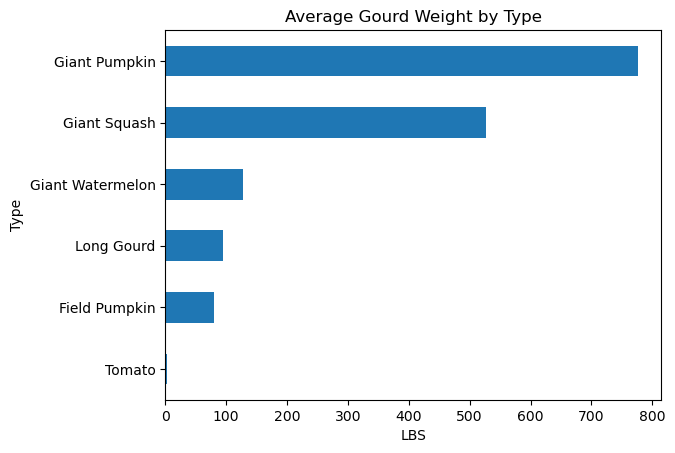

In [9]:
(
    gourds
    .groupby("type")['weight_lbs']
    .mean()
    .sort_values()
    .plot(kind="barh", title="Average Gourd Weight by Type", xlabel="LBS", ylabel="Type")
)

## 9. Create a visualization to compare the estimated weight (`est_weight`) to the actual weight (`weight_lbs`).
What do you notice?

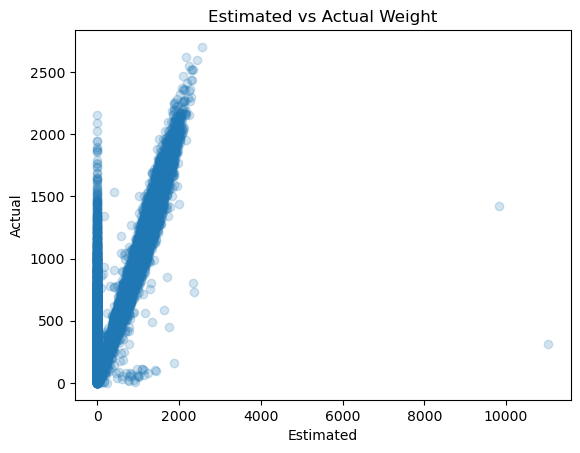

In [10]:
ax = plt.scatter(x=gourds['est_weight'], y=gourds['weight_lbs'], alpha=0.2)
plt.title("Estimated vs Actual Weight")
plt.xlabel("Estimated")
plt.ylabel("Actual");

### ANSWER: Looks like the actual weights outperform the estimated weights in most cases.

## 10. Create a new column `weight_error` that contains the amount by which the estimated weight exceeded the actual weight.
What is the worst overestimate of a gourd weight? What percentage of gourd weights are overestimated?

In [11]:
gourds['weight_error'] = gourds['est_weight'] - gourds['weight_lbs']

In [12]:
print(f"WORST OVERESTIVMATE GOURD WEIGHT: {gourds['weight_error'].max()}")

WORST OVERESTIVMATE GOURD WEIGHT: 10717.0


In [13]:
print(f"GOURD WEIGHTS OVERESTIMATED: {((gourds['weight_error'] > 0).sum() / gourds['weight_error'].size) * 100:.3f}%")

GOURD WEIGHTS OVERESTIMATED: 30.063%


## 11. Some growers compete across multiple types of gourd.
Which grower has **top 10** finishes across the largest number of types of gourds? What is this grower's best finish in the GPC Weighoff in the years that are covered in this dataset?

In [57]:
grower = (
    gourds[gourds['place'] <= 10] # Filter the gourds that placed in the top 10
    .groupby("grower_name")['type'] # Get type by grower
    .unique() # Filter by unique types
    .sort_values(key=lambda x: x.str.len(), ascending=False) # Sorty by type list length
    .head(1) # Filter the most types
    .idxmax() # Get the max index
)
print(f"ANSWER: {grower}")

ANSWER: Martin, Margaret & Glen


In [61]:
# Filter by grower and highest placement
gourds[gourds['grower_name'] == grower].sort_values(by="place").head(1)

,id,place,weight_lbs,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,variety,place_bk,year_bk,type_bk,year,type,weight_error
5496,2014-T,2.0,7.45,"Martin, Margaret & Glen",Combined Locks,Wisconsin,United States,Cedarburg Wine and Harvest Festival,5.63 Martin uof '13 (big zac),open,NaN,NaN,Big Zac,2.0,2014,T,2014,Tomato,NaN


## 12. How many gourds have at least 100 offspring that have appeared in the GPC Weighoff?
You can count a pumpkin as having an offspring if it is either the seed_mother or pollinator_father. Hint: One way you could do this is to create two `value_counts` Series on the `seed_mother` and `pollinator_father` columns and merge them.

In [91]:
# Get a series of seed mothers and their number of entries
seed_mother = gourds.groupby("seed_mother")['seed_mother'].count()

# Get a series of pollinator fathers and their number of entries
pollinator_father = gourds.groupby("pollinator_father")['pollinator_father'].count()

# Combine the two series
parents = pd.concat(objs=[seed_mother, pollinator_father])

# Count how many gourds have 100 or more entries
parents[parents >= 100].count()

np.int64(12)